# Tiền xử lý dữ liệu

### Import thư viện

In [47]:
# Data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots in notebook
%matplotlib inline

# Regex
import re

# Path
import os

# Split data and scale features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data directory
DATA_DIR = os.path.join(os.getcwd(), "..", "data")
print("Data directory:", DATA_DIR)

Data directory: c:\Users\ADMIN\OneDrive\Desktop\Housing-Market-Prediction\Nhom20\notebooks\..\data


## 1. Nạp dữ liệu

In [48]:
df = pd.read_csv(os.path.join(DATA_DIR, "raw", "data_public.csv"))

# Show the first 5 rows of the dataframe
df.head()

,Title,Price,Area,Location,Listing ID,Last Updated,Property Type,Width,Length,Bedrooms,...,Longitude,VIP Account,Avatar,Agent Role,Agent Name,Agent Listing Count,Province,Property Type Slug,Scraped At,Last Updated Date
0,"🏠 NHÀ 3 TẦNG – TRUNG TÂM PHƯỚC LONG B, THỦ ĐỨC",7500.0,95.0,"Phường Phước Long,TP. Hồ Chí Minh",1546393.0,2 giờ trước,Nhà riêng,5.0,17.0,3.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
1,🔥🔥 NHÀ ĐẸP HIỆP BÌNH PHƯỚC – HẺM XE HƠI – KHU ...,4500.0,66.0,"đường Hiệp Bình,Phường Hiệp Bình Chánh,Quận Th...",1528310.0,2 giờ trước,Nhà riêng,4.0,NaN,2.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
2,🌟 HXH - NHÀ 3 TẦNG ĐẸP – TRUNG TÂM PHƯỚC LONG ...,7500.0,92.0,"Phường Phước Long B,Quận 9,TP. Hồ Chí Minh",1546519.0,2 giờ trước,Nhà riêng,5.0,17.0,3.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
3,🏡 HÀNG HIẾM LINH CHIỂU – NHÀ 2 TẦNG – VỊ TRÍ V...,4750.0,45.0,"đường số 19,Phường Linh Chiểu,Quận Thủ Đức,TP....",1544240.0,2 giờ trước,Nhà riêng,4.0,11.5,3.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24
4,🚗 NHÀ ĐẸP HẺM XE HƠI – VỊ TRÍ VIP LINH TÂY – G...,4800.0,82.0,"đường số 9,Phường Linh Tây,Quận Thủ Đức,TP. Hồ...",1528291.0,2 giờ trước,Nhà riêng,8.5,NaN,2.0,...,NaN,False,1,Môi giới,Ngô Quang Tùng,20.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:18,30/09/2025 16:24


## 2. Dọn dẹp dữ liệu trùng và không hợp lệ

#### 2.1. Dọn dẹp dữ liệu không hợp lệ

In [49]:
print("Dataset shape before removing invalid rows:", df.shape)

# Drop rows with non-positive price or area
df = df[
    (df["Price"] > 0) &
    (df["Area"] > 0)
]

print("Dataset shape after removing invalid rows:", df.shape)

Dataset shape before removing invalid rows: (51304, 28)
Dataset shape after removing invalid rows: (51182, 28)


#### 2.2. Dọn dẹp dữ liệu trùng

In [50]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicated rows:", duplicate_count)

# Remove duplicate rows and reset index
df = df.drop_duplicates()

duplicate_count_after = df.duplicated().sum()

print("Number of duplicated rows after dropping duplicates:", duplicate_count_after)

df = df.reset_index(drop=True)

Number of duplicated rows: 0
Number of duplicated rows after dropping duplicates: 0


## 3. Xử lý outliers

### 3.1. Trực quan hóa phân phối giá trên mét vuông

In [51]:
# Create new feature "price_per_m2" to identify outliers
df["price_per_m2"] = df["Price"] / df["Area"]

df[["Price", "Area", "price_per_m2"]].head()

,Price,Area,price_per_m2
0,7500.0,95.0,78.947368
1,4500.0,66.0,68.181818
2,7500.0,92.0,81.521739
3,4750.0,45.0,105.555556
4,4800.0,82.0,58.536585


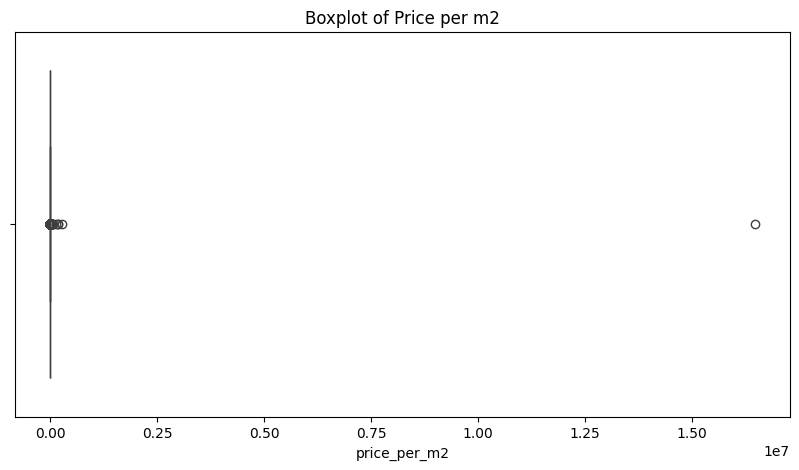

In [52]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["price_per_m2"])

plt.title("Boxplot of Price per m2")

plt.show()

#### 3.1.1. Sử dụng IQR để xác định bound của outlier

In [53]:
# Tính IQR để xác định ngưỡng ngoại lệ
Q1 = df["price_per_m2"].quantile(0.25)
Q3 = df["price_per_m2"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 16.666666666666668
Q3: 100.01320422535211
IQR: 83.34653755868544
Lower Bound: -108.35313967136149
Upper Bound: 225.0330105633803


#### 3.1.2. Xác định outlier

In [54]:
outliers = df[
    (df["price_per_m2"] < lower_bound) |
    (df["price_per_m2"] > upper_bound)
]

print("Number of outliers:", outliers.shape[0])

outliers.head()

Number of outliers: 6218


,Title,Price,Area,Location,Listing ID,Last Updated,Property Type,Width,Length,Bedrooms,...,VIP Account,Avatar,Agent Role,Agent Name,Agent Listing Count,Province,Property Type Slug,Scraped At,Last Updated Date,price_per_m2
12,"Nhà Biệt Thự ✅ Khu Nam Thông Q7, 15x18❤️270m2,...",115000.0,303.0,"Phường Bình Trưng,TP. Hồ Chí Minh(Mới)",1366556.0,1 ngày trước,Nhà riêng,15.0,18.0,7.0,...,False,1,Môi giới,Phạm Đức Thắng,272.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:19,29/09/2025 18:24,379.537954
19,Nhà Mặt tiền Liên Phường 30m thông qua nhiều Q...,25000.0,100.0,"Phường Phước Long,TP. Hồ Chí Minh(Mới)",1216780.0,4 giờ trước,Nhà riêng,5.0,20.0,7.0,...,False,1,Chính chủ,Tân PP,7.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:19,30/09/2025 14:24,250.000000
32,Bán nhà 130.8m² ngang 6.8m giá 33 tỷ Phường Bì...,33000.0,130.8,"Phường Bình Trưng,TP. Hồ Chí Minh(Mới)",1536574.0,25 phút trước,Nhà riêng,6.8,NaN,NaN,...,False,1,Môi giới,Lê Công Tiến,93.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:21,30/09/2025 17:59,252.293578
43,Bán nhà 84.4m² ngang 5.9m Phường Bình Trưng,72000.0,84.4,"Phường Bình Trưng,TP. Hồ Chí Minh(Mới)",1339055.0,25 phút trước,Nhà riêng,5.9,NaN,NaN,...,False,1,Môi giới,Lê Công Tiến,93.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:21,30/09/2025 17:59,853.080569
47,Bán nhà 358.5m² ngang 10m giá 93 tỷ tại Phường...,93000.0,358.5,"Phường Cát Lái,TP. Hồ Chí Minh(Mới)",1303493.0,25 phút trước,Nhà riêng,10.0,NaN,NaN,...,False,1,Môi giới,Lê Công Tiến,93.0,tp-ho-chi-minh,nha-mat-pho-mat-tien,2025-09-30 18:24:27,30/09/2025 17:59,259.414226


### 3.2. Xác định thêm đặc trưng để xét outlier

#### 3.2.1 Sử dụng regex để xác định thêm đặc trưng

In [55]:
luxury_keywords = [
    "villa",
    "penthouse",
    "cao cấp",
    "mặt tiền",
    "view sông",
    "biệt thự",
    "resort"
]

# Create regex pattern
pattern = "|".join(luxury_keywords)

# Create is_luxury column
df["is_luxury"] = (
    (
        df["Title"].fillna("") + " " +
        df["Description"].fillna("")
    )
    .str.lower()
    .str.contains(pattern, regex=True)
    .astype(int)
)

df[["Title", "is_luxury"]].head()

,Title,is_luxury
0,"🏠 NHÀ 3 TẦNG – TRUNG TÂM PHƯỚC LONG B, THỦ ĐỨC",1
1,🔥🔥 NHÀ ĐẸP HIỆP BÌNH PHƯỚC – HẺM XE HƠI – KHU ...,0
2,🌟 HXH - NHÀ 3 TẦNG ĐẸP – TRUNG TÂM PHƯỚC LONG ...,1
3,🏡 HÀNG HIẾM LINH CHIỂU – NHÀ 2 TẦNG – VỊ TRÍ V...,0
4,🚗 NHÀ ĐẸP HẺM XE HƠI – VỊ TRÍ VIP LINH TÂY – G...,0


#### 3.2.2. Thông số đặc trưng mới

In [56]:
df["is_outlier"] = (
    (df["price_per_m2"] < lower_bound) |
    (df["price_per_m2"] > upper_bound)
).astype(int)

df["is_outlier"].value_counts()

is_outlier
0    44964
1     6218
Name: count, dtype: int64

### 3.3. Kết hợp các đặc trưng để đánh dấu các outlier nên loại bỏ

#### 3.3.1. Thông số đặc trưng đánh dấu

In [57]:
df["is_suspicious"] = (
    (df["is_outlier"] == 1) &
    (df["is_luxury"] == 0)
).astype(int)

df["is_suspicious"].value_counts()

is_suspicious
0    48120
1     3062
Name: count, dtype: int64

In [58]:
suspicious_df = df[df["is_suspicious"] == 1]

suspicious_df[
    [
        "Price",
        "Area",
        "price_per_m2",
        "Location",
        "Property Type",
        "Title",
        "is_luxury"
    ]
].head(20)

,Price,Area,price_per_m2,Location,Property Type,Title,is_luxury
32,33000.0,130.8,252.293578,"Phường Bình Trưng,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 130.8m² ngang 6.8m giá 33 tỷ Phường Bì...,0
43,72000.0,84.4,853.080569,"Phường Bình Trưng,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 84.4m² ngang 5.9m Phường Bình Trưng,0
56,45000.0,160.0,281.250000,"Phường Cát Lái,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 160m² ngang 8m giá 45 tỷ tại Phường Th...,0
64,36500.0,68.6,532.069971,"Phường Sài Gòn,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 68.6m² giá 36.5 tỷ Phường Sài Gòn,0
69,55000.0,74.4,739.247312,"Phường Sài Gòn,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 74.4m² giá 55 tỷ Phường Sài Gòn,0
70,450000.0,450.8,998.225377,"Phường Bến Thành,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 450.8m² giá 450 tỷ Phường Bến Thành,0
73,900000.0,452.2,1990.269792,"Phường Bến Thành,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 452.2m² giá 900 tỷ Phường Bến Thành,0
77,80000.0,85.4,936.768150,"Phường Bến Thành,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 85.4m² giá 80 tỷ Phường Bến Thành,0
79,11600.0,18.4,630.434783,"Phường Sài Gòn,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 18.4m² giá 11.6 tỷ Phường Sài Gòn,0
81,3500000.0,1400.0,2500.000000,"Phường Sài Gòn,TP. Hồ Chí Minh(Mới)",Nhà riêng,Bán nhà 1400m² giá 3500 tỷ Phường Sài Gòn,0


#### 3.3.2. Kích thước dataset sau khi dọn ngoại lệ

In [59]:
print("Dataset shape before filtering:", df.shape)

df = df[
    ~(
        (df["is_suspicious"] == 1) &
        (df["Area"] < 15)
    )
]

print("Dataset shape after filtering:", df.shape)

df.reset_index(drop=True)
df.drop(
    columns=[
        "price_per_m2",
        "is_outlier",
        "is_suspicious"
    ],
    inplace=True
)

Dataset shape before filtering: (51182, 32)
Dataset shape after filtering: (51162, 32)


## 4. Xử lý missing values

### 4.1. Thông số missing values của các đặc trưng

In [60]:
numeric_cols = [
    "Price",
    "Area",
    "Width",
    "Length",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "Alley Width",
    "Latitude",
    "Longitude",
    "Agent Listing Count"
]

missing_df = pd.DataFrame({
    "Missing Count": df[numeric_cols].isnull().sum(),
    "Missing Percent (%)": (
        df[numeric_cols].isnull().sum() / len(df)
    ) * 100
})

# Sort by missing percentage
missing_df = missing_df.sort_values(
    by="Missing Percent (%)",
    ascending=False
)

# Round percentage
missing_df["Missing Percent (%)"] = (
    missing_df["Missing Percent (%)"]
    .round(2)
)

missing_df

,Missing Count,Missing Percent (%)
Floors,42502,83.07
Bathrooms,40414,78.99
Alley Width,38927,76.09
Bedrooms,34551,67.53
Longitude,29731,58.11
Latitude,29731,58.11
Length,25954,50.73
Width,16947,33.12
Price,0,0.00
Area,0,0.00


### 4.2. Thay thế bằng median

In [61]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Check missing values again
missing_df_after = pd.DataFrame({
    "Missing Count": df[numeric_cols].isnull().sum(),
    "Missing Percent (%)": (
        df[numeric_cols].isnull().sum() / len(df)
    ) * 100
})

missing_df_after

,Missing Count,Missing Percent (%)
Price,0,0.0
Area,0,0.0
Width,0,0.0
Length,0,0.0
Bedrooms,0,0.0
Bathrooms,0,0.0
Floors,0,0.0
Alley Width,0,0.0
Latitude,0,0.0
Longitude,0,0.0


## 5. One-Hot encoding

### 5.1. Regex đặc trưng "Location"

In [62]:
df["District"] = df["Location"].str.extract(
    r"(Quận\s+\d+|Quận\s+\w+|Huyện\s+\w+|TP\.\s*\w+)"
)

df["District"] = df["District"].fillna("Unknown")

### 5.2. Xử lý giá trị thiếu

In [63]:
categorical_cols = [
    "District",
    "Property Type",
    "Position",
    "Direction",
    "Road Type",
    "Agent Role",
    "VIP Account"
]

# Check missing values in categorical columns
print("Missing values in categorical columns before filling:")
print(df[categorical_cols].isnull().sum())

# Fill missing values in categorical columns with "Unknown"
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")
    
# Recheck missing values
print("\n\nMissing values in categorical columns after filling:")
print(df[categorical_cols].isnull().sum())

Missing values in categorical columns before filling:
District             0
Property Type        0
Position         21817
Direction        40506
Road Type        37013
Agent Role           0
VIP Account          0
dtype: int64


Missing values in categorical columns after filling:
District         0
Property Type    0
Position         0
Direction        0
Road Type        0
Agent Role       0
VIP Account      0
dtype: int64


### 5.3. Xử lý One-Hot encoding

In [ ]:
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

## 6. Dọn dẹp các đặc trưng không cần thiết

In [ ]:
# Final cleanup
drop_cols = [
    "Listing ID",
    "Title",
    "Description",
    "Avatar",
    "Agent Name",
    "Last Updated",
    "Scraped At",
    "Last Updated Date",
    "Property Type Slug",
    "Location",
    "Province",
]
df.drop(columns=drop_cols, inplace=True)


print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (51162, 58)


,Price,Area,Width,Length,Bedrooms,Bathrooms,Floors,Alley Width,Latitude,Longitude,...,Direction_Tây Nam,Direction_Unknown,Direction_Đông,Direction_Đông Bắc,Direction_Đông Nam,Road Type_Đường bê tông,Road Type_Đường nhựa,Road Type_Đường đá,Road Type_Đường đất,Agent Role_Môi giới
0,7500.0,95.0,5.0,17.0,3.0,3.0,3.0,8.0,10.909222,106.671483,...,False,False,False,False,False,False,False,False,False,True
1,4500.0,66.0,4.0,22.0,2.0,2.0,2.0,8.0,10.909222,106.671483,...,False,False,False,False,False,False,False,False,False,True
2,7500.0,92.0,5.0,17.0,3.0,3.0,3.0,8.0,10.909222,106.671483,...,False,False,False,True,False,False,False,False,False,True
3,4750.0,45.0,4.0,11.5,3.0,2.0,2.0,8.0,10.909222,106.671483,...,False,False,False,False,True,False,False,False,False,True
4,4800.0,82.0,8.5,22.0,2.0,1.0,1.0,8.0,10.909222,106.671483,...,False,False,False,False,False,False,False,False,False,True


## 7. Lưu lại Clean Dataset

In [65]:
# Save the cleaned dataset
processed_dir = "../data/processed"

os.makedirs(processed_dir, exist_ok=True)

processed_data_path = os.path.join(
    processed_dir,
    "data.csv"
)

df.to_csv(processed_data_path, index=False)

print("Saved cleaned dataset to:", processed_data_path)

Saved cleaned dataset to: ../data/processed\data.csv


## 8. Chia tập dữ liệu train/test

### 8.1. Chia dữ liệu và log transform target "Price"

In [66]:
# Split features and target
X = df.drop(columns=["Price"])
y = df["Price"]

# Log transform target "Price"
y = np.log1p(y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Identify numerical columns for scaling
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_cols)

X_train shape: (40929, 57)
X_test shape: (10233, 57)
Index(['Area', 'Width', 'Length', 'Bedrooms', 'Bathrooms', 'Floors',
       'Alley Width', 'Latitude', 'Longitude', 'Agent Listing Count',
       'is_luxury'],
      dtype='object')


### 8.2. Chuẩn hóa dữ liệu

In [67]:
scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

### 8.3. Lưu tập dữ liệu train/test

In [68]:
# Combine features and target for saving
train_df = X_train.copy()
train_df["Price"] = y_train

test_df = X_test.copy()
test_df["Price"] = y_test

# Save train and test datasets
train_df.to_csv(
    os.path.join(processed_dir, "train.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(processed_dir, "test.csv"),
    index=False
)

print("Train and test datasets saved successfully.")

Train and test datasets saved successfully.
